<a href="https://colab.research.google.com/github/Leonardopedroti/Modelo-de-treinamento-para-classifica-o-de-solo/blob/main/Modelo_de_treinamento_para_classifica%C3%A7%C3%A3o_de_solo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Definição de amostras e classes para treinamento
'amostras' deve ser um array de índices de pixels que você selecionou
para serem seus dados de treinamento. Estes índices correspondem às linhas
no array 'bandas'.
'classes' deve ser um array com os rótulos de classe (inteiros) correspondentes
para cada pixel em 'amostras'.

EXEMPLO: Definição de amostras e classes fictícias para demonstração.
No seu caso, você deve carregar ou coletar seus dados de ground truth (solo verdadeiro).
Para este exemplo, eu selecionei 100 índices de pixels aleatórios e atribuímos classes aleatórias (por exemplo, 0, 1 ou 2).
ATENÇÃO: Isso é apenas para fazer o código rodar. Você DEVE substituir isso com seus dados de treinamento reais!


In [ ]:
import rasterio
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Abrir imagem
with rasterio.open("/content/camada_satelite.tiff") as src:
    img = src.read()

# Organizar bandas
bandas = img.reshape(img.shape[0], -1).T

# Obtenha o número total de pixels para garantir que os índices sejam válidos
num_pixels = bandas.shape[0]

np.random.seed(42) # Para reprodutibilidade do exemplo
amostras = np.random.choice(num_pixels, size=100, replace=False) # 100 índices de pixels aleatórios
classes = np.random.randint(0, 3, size=100) # 100 rótulos de classe fictícios (0, 1, 2)

# Dados de treinamento
X_train = bandas[amostras]
y_train = classes

# Treinar modelo
modelo = RandomForestClassifier(n_estimators=100)
modelo.fit(X_train, y_train)

# Classificação
resultado = modelo.predict(bandas)

# Voltar formato original
mapa = resultado.reshape(img.shape[1], img.shape[2])

## Geração de mapa de classificação

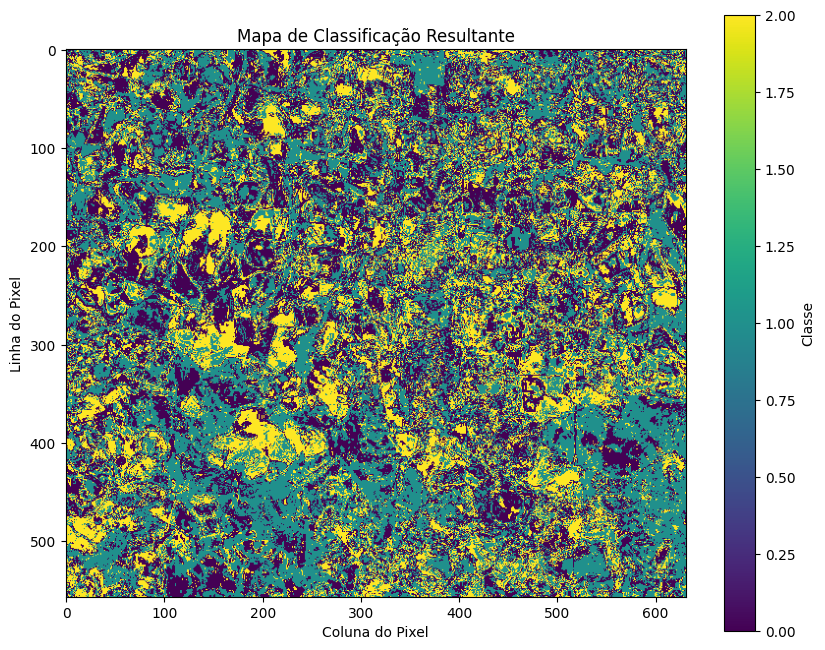

In [ ]:
import matplotlib.pyplot as plt

# Exibir o mapa de classificação
plt.figure(figsize=(10, 8))
plt.imshow(mapa, cmap='viridis') # 'viridis' é um bom colormap para dados categóricos
plt.title('Mapa de Classificação Resultante')
plt.colorbar(label='Classe')
plt.xlabel('Coluna do Pixel')
plt.ylabel('Linha do Pixel')
plt.show()

## Criação de arquivo "shapefile"

In [ ]:
import rasterio
import rasterio.features
import fiona
from shapely.geometry import shape, mapping

# Abrir a imagem original novamente para obter metadados (CRS, transform)
with rasterio.open("/content/camada_satelite.tiff") as src_original:
    transform = src_original.transform
    crs = src_original.crs

# Definir o caminho de saída para o shapefile
output_shapefile = "/content/mapa_classificacao.shp"

# Definir o esquema para o shapefile
schema = {
    'geometry': 'Polygon',
    'properties': {'class_id': 'int'},
}

# Criar o shapefile
with fiona.open(
    output_shapefile,
    'w',
    driver='ESRI Shapefile',
    crs=crs,
    transform=transform, # Adicionar transform aqui para compatibilidade, embora fiona use crs
    schema=schema
) as collection:
    # Gerar geometrias a partir do mapa de classificação
    # `mapa` deve ser um array 2D com as classes
    for i, (geom, value) in enumerate(rasterio.features.shapes(mapa, transform=transform)):
        # Criar um polígono Shapely a partir da geometria
        poly = shape(geom)

        # Escrever a feição no shapefile
        collection.write({
            'geometry': mapping(poly),
            'properties': {'class_id': int(value)},
        })

print(f"Shapefile '{output_shapefile}' gerado com sucesso!")

Shapefile '/content/mapa_classificacao.shp' gerado com sucesso!
